# Cloud FinOps Cost Analytics Case Study

This notebook analyzes a cloud budget dataset to simulate the work of a Junior Cloud FinOps Analyst.

The goal is to analyze cloud spend, compare actual costs against budget and forecast, detect anomalies, identify cost drivers, and generate cost optimization recommendations.

### 2. Importação das Bibliotecas | Importing Libraries

In [11]:

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

### 3. Carregamento dos Arquivos CSV | Loading CSV Files

In [5]:
original = pd.read_csv('cloud_budget_2023_dataset.csv')
daily = pd.read_csv('cloud_budget_2023_dataset_daily_account_summary.csv')
monthly = pd.read_csv('cloud_budget_2023_dataset_monthly_account_summary.csv')

original.head()

,date,year,month,day,day_of_week,is_month_start,is_month_end,cloud_provider,account_id,project_id,environment,business_unit,department,cost_center,region,service,resource_type,usage_quantity,usage_unit,list_cost,savings_plan_coverage_pct,reserved_instance_coverage_pct,discount_rate_pct,discount_amount,net_cost,on_demand_cost,reserved_savings,savings_plan_savings,spot_savings,amortized_cost,forecast_monthly_cost,budget_amount,budget_utilization_pct,budget_status,cost_variance_7d_pct,cost_variance_30d_pct,anomaly_score,is_anomaly,currency,tags
0,2023-01-01,2023,1,1,6,1,0,AWS,acct-001,project-001,staging,Finance,Mobile,CC-1004,us-west-2,Serverless,ObjectStorage,53.00,request-million,4.77,0.62,0.02,0.20,0.94,3.83,1.37,0.01,0.34,0.00,3.48,3.83,"15,403.12",0.00,under,-0.23,-0.22,0.42,0,USD,team=Mobile;bu=Finance;env=staging;provider=AW...
1,2023-01-01,2023,1,1,6,1,0,Azure,acct-001,project-002,prod,Marketing,BI,CC-1010,us-east-1,Container,BlockStorage,103.67,container-hours,12.44,0.24,0.09,0.39,4.79,7.65,5.11,0.13,0.22,0.00,7.30,7.65,"44,192.54",0.00,under,0.26,0.14,0.45,0,USD,team=BI;bu=Marketing;env=prod;provider=Azure;s...
2,2023-01-01,2023,1,1,6,1,0,AWS,acct-001,project-003,staging,HR,DataPlatform,CC-1007,ap-south-1,Database,LoadBalancer,45.78,DB-hours,5.95,0.49,0.01,0.13,0.77,5.18,2.58,0.01,0.30,0.00,4.88,5.18,"13,972.15",0.00,under,-0.19,-0.15,0.36,0,USD,team=DataPlatform;bu=HR;env=staging;provider=A...
3,2023-01-01,2023,1,1,6,1,0,GCP,acct-001,project-004,prod,Engineering,Mobile,CC-1004,eu-west-1,Serverless,ObjectStorage,86.57,request-million,7.79,0.12,0.44,0.11,0.84,6.96,3.08,0.59,0.25,0.00,6.11,6.96,"53,700.00",0.00,under,0.08,0.22,0.39,0,USD,team=Mobile;bu=Engineering;env=prod;provider=G...
4,2023-01-01,2023,1,1,6,1,0,Azure,acct-001,project-005,staging,Marketing,DataPlatform,CC-1006,eu-west-1,Compute,RDS,66.68,vCPU-hours,9.33,0.40,0.14,0.12,1.16,8.17,3.75,0.26,0.90,1.46,5.55,8.17,"13,500.08",0.00,under,-0.17,0.27,0.37,0,USD,team=DataPlatform;bu=Marketing;env=staging;pro...


### 4. Análise de Qualidade dos Dados | Data Quality Analysis

In [6]:
print("Original dataset:", original.shape)
print("Daily summary:", daily.shape)
print("Monthly summary:", monthly.shape)

Original dataset: (54750, 40)
Daily summary: (24446, 15)
Monthly summary: (360, 15)


#### The original dataset provides the most granular view of cloud costs, including service, resource type, account, project, business unit,environment,region, discount, savings, forecast, budget and anomaly indicators. 

#### 
The daily summary is useful for daily cost monitoring and anomaly trackin

#### 

The monthly summary is useful for executive reporting, budget tracking and forecast analysis.

In [8]:
missing_values = original.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

Series([], dtype: int64)

In [9]:
original["date"] = pd.to_datetime(original["date"])
daily["date"] = pd.to_datetime(daily["date"])

original["year_month"] = original["date"].dt.to_period("M").astype(str)
daily["year_month"] = daily["date"].dt.to_period("M").astype(str)

### 5. KPIs Principais de FinOps | Main FinOps KPIs                                                                                                   

#### This section calculates the main FinOps KPIs, such as total list cost, total net cost, total discount, Reserved Instance savings, Savings Plan savings, Spot savings and anomaly count.

#### These KPIs provide a high-level view of cloud financial performance.

In [10]:
total_list_cost = original["list_cost"].sum()
total_net_cost = original["net_cost"].sum()
total_discount = original["discount_amount"].sum()
total_reserved_savings = original["reserved_savings"].sum()
total_savings_plan_savings = original["savings_plan_savings"].sum()
total_spot_savings = original["spot_savings"].sum()
total_anomalies = original["is_anomaly"].sum()

summary_kpis = pd.DataFrame({
    "KPI": [
        "Total List Cost",
        "Total Net Cost",
        "Total Discount",
        "Reserved Instance Savings",
        "Savings Plan Savings",
        "Spot Savings",
        "Total Anomalies"
    ],
    "Value": [
        total_list_cost,
        total_net_cost,
        total_discount,
        total_reserved_savings,
        total_savings_plan_savings,
        total_spot_savings,
        total_anomalies
    ]
})

summary_kpis

,KPI,Value
0,Total List Cost,"526,500.21"
1,Total Net Cost,"407,980.00"
2,Total Discount,"118,520.22"
3,Reserved Instance Savings,"23,612.70"
4,Savings Plan Savings,"27,578.24"
5,Spot Savings,"2,413.56"
6,Total Anomalies,0.00


### These KPIs summarize the cloud financial position. List cost represents the gross cloud cost before discounts. Net cost represents the actual cost after discounts. Savings metrics help evaluate the impact of optimization strategies such as Reserved Instances, Savings Plans and Spot usage.

#### 6. Análise por Cloud Provider | Cloud Provider Analysis

This section compares cloud costs across providers such as AWS, Azure and GCP.

The goal is to identify which cloud provider contributes the most to total cloud spend and where optimization efforts should be prioritized.

In [12]:
cost_by_provider = (
    original
    .groupby("cloud_provider", as_index=False)
    .agg(
        total_list_cost=("list_cost", "sum"),
        total_net_cost=("net_cost", "sum"),
        total_discount=("discount_amount", "sum"),
        anomaly_count=("is_anomaly", "sum")
    )
    .sort_values("total_net_cost", ascending=False)
)

cost_by_provider

,cloud_provider,total_list_cost,total_net_cost,total_discount,anomaly_count
0,AWS,"184,909.04","143,328.96","41,580.08",0
1,Azure,"173,137.81","134,175.77","38,962.05",0
2,GCP,"168,453.36","130,475.27","37,978.10",0


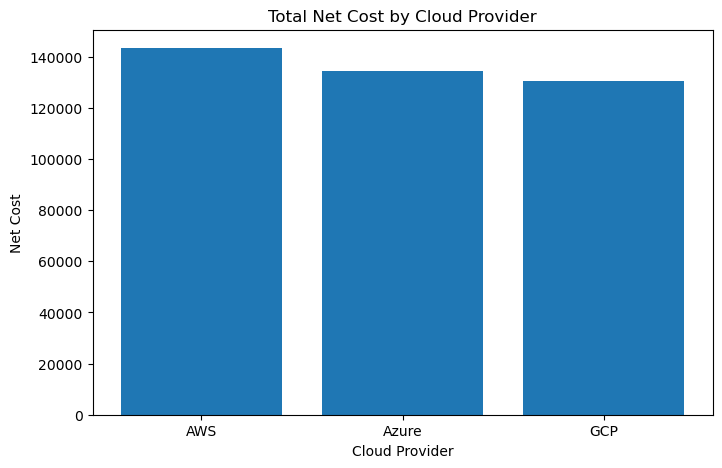

In [13]:
plt.figure(figsize=(8, 5))
plt.bar(cost_by_provider["cloud_provider"], cost_by_provider["total_net_cost"])
plt.title("Total Net Cost by Cloud Provider")
plt.xlabel("Cloud Provider")
plt.ylabel("Net Cost")
plt.show()

## 7. Análise por Ambiente | Environment Analysis


This section compares costs across environments such as production, staging and development.

Environment-level analysis helps identify whether non-production environments are generating unnecessary costs.

In [14]:
cost_by_environment = (
    original
    .groupby("environment", as_index=False)
    .agg(
        total_net_cost=("net_cost", "sum"),
        total_list_cost=("list_cost", "sum"),
        anomaly_count=("is_anomaly", "sum")
    )
    .sort_values("total_net_cost", ascending=False)
)

cost_by_environment

,environment,total_net_cost,total_list_cost,anomaly_count
1,prod,"317,599.06","410,105.40",0
2,staging,"66,783.47","85,982.09",0
0,dev,"23,597.46","30,412.73",0


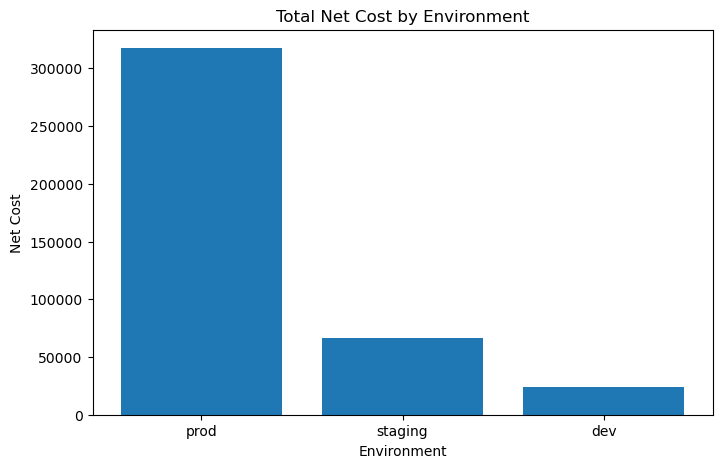

In [15]:
plt.figure(figsize=(8, 5))
plt.bar(cost_by_environment["environment"], cost_by_environment["total_net_cost"])
plt.title("Total Net Cost by Environment")
plt.xlabel("Environment")
plt.ylabel("Net Cost")
plt.show()

## 8. Top Serviços por Custo | Top Services by Cost

This section identifies the services with the highest net cost.

FinOps teams use this analysis to focus optimization efforts on the services with the greatest financial impact.

In [17]:
cost_by_service = (original.groupby("service",as_index=False).agg(total_net_cost=("net_cost","sum"),
                                                                  total_list_cost=("list_cost","sum"),
                                                                  total_discount=("discount_amount","sum"),
                                                                  anomaly_count=("is_anomaly","sum")
                                                                 ).sort_values("total_net_cost", ascending=False)
                  )
cost_by_service

,service,total_net_cost,total_list_cost,total_discount,anomaly_count
0,Analytics,"77,120.11","99,579.37","22,459.25",0
1,Compute,"71,655.41","92,530.42","20,875.01",0
3,Database,"65,975.90","85,165.26","19,189.37",0
2,Container,"62,483.74","80,671.42","18,187.68",0
6,Storage,"49,784.20","64,192.43","14,408.22",0
5,Serverless,"46,086.44","59,331.45","13,245.02",0
4,Networking,"34,874.19","45,029.86","10,155.66",0


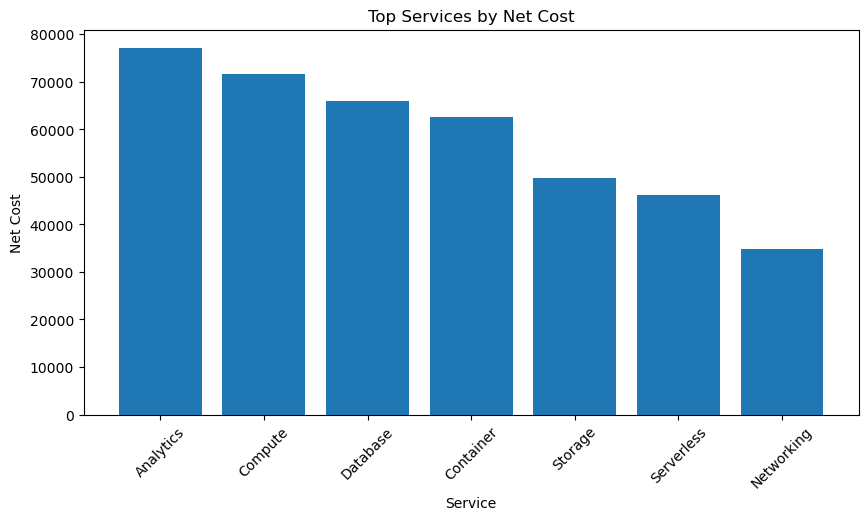

In [18]:
top_services = cost_by_service.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_services["service"], top_services["total_net_cost"])
plt.title("Top Services by Net Cost")
plt.xlabel("Service")
plt.ylabel("Net Cost")
plt.xticks(rotation=45)
plt.show()

## 9. Análise por Tipo de Recurso | Resource Type Analysis

This section analyzes cloud costs by resource type, such as virtual machines, storage, databases, containers and serverless functions.

This helps generate more specific optimization recommendations.

In [19]:
cost_by_resource = (
    original
    .groupby("resource_type", as_index=False)
    .agg(
        total_net_cost=("net_cost", "sum"),
        total_usage=("usage_quantity", "sum"),
        anomaly_count=("is_anomaly", "sum")
    )
    .sort_values("total_net_cost", ascending=False)
)

cost_by_resource.head(10)

,resource_type,total_net_cost,total_usage,anomaly_count
6,ObjectStorage,"45,872.56","514,245.64",0
7,RDS,"45,649.65","509,333.94",0
3,LambdaFunction,"45,648.89","516,692.99",0
5,NoSQL,"45,636.41","514,273.04",0
8,VM,"45,386.40","515,472.66",0
2,KubernetesCluster,"45,110.44","508,460.09",0
4,LoadBalancer,"45,037.97","507,661.22",0
0,BlockStorage,"44,919.93","504,066.36",0
1,DataWarehouse,"44,717.73","506,413.69",0


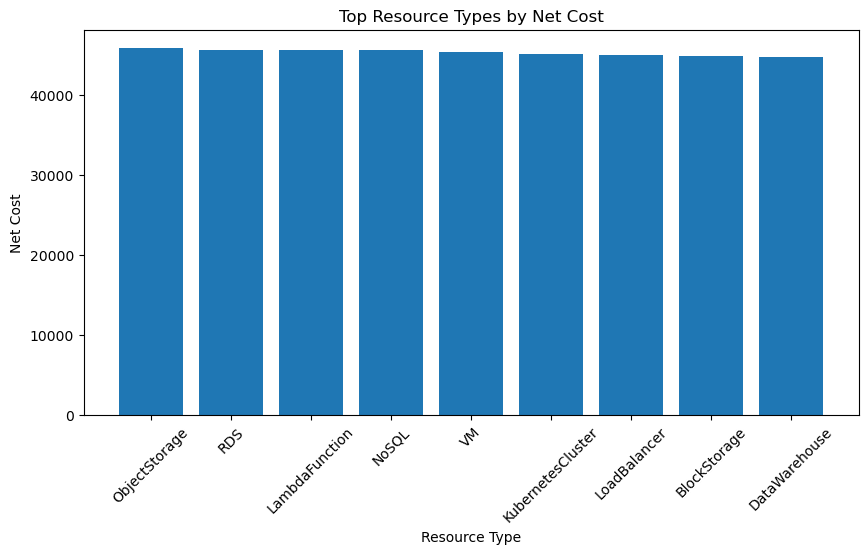

In [20]:
top_resources = cost_by_resource.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_resources["resource_type"], top_resources["total_net_cost"])
plt.title("Top Resource Types by Net Cost")
plt.xlabel("Resource Type")
plt.ylabel("Net Cost")
plt.xticks(rotation=45)
plt.show()

## 10. Budget vs Custo Real | Budget vs Actual Cost

This section compares actual cloud spend against the allocated budget.

Budget tracking helps identify whether cloud usage is aligned with financial planning.

In [21]:
budget_analysis = (
    monthly
    .groupby(["year", "month"], as_index=False)
    .agg(
        total_net_cost=("total_net_cost", "sum"),
        total_budget=("total_budget_amount", "sum"),
        avg_budget_utilization_pct=("avg_budget_utilization_pct", "mean")
    )
)

budget_analysis["budget_variance"] = budget_analysis["total_net_cost"] - budget_analysis["total_budget"]
budget_analysis["budget_variance_pct"] = budget_analysis["budget_variance"] / budget_analysis["total_budget"]

budget_analysis

,year,month,total_net_cost,total_budget,avg_budget_utilization_pct,budget_variance,budget_variance_pct
0,2023,1,"29,886.60","168,257,315.62",0.00,"-168,227,429.02",-1.00
1,2023,2,"29,145.86","149,132,503.39",0.00,"-149,103,357.53",-1.00
2,2023,3,"33,317.25","167,620,443.43",0.00,"-167,587,126.18",-1.00
3,2023,4,"31,226.57","161,313,942.03",0.00,"-161,282,715.46",-1.00
4,2023,5,"32,336.58","167,185,492.14",0.00,"-167,153,155.56",-1.00
5,2023,6,"36,288.11","161,413,622.94",0.00,"-161,377,334.83",-1.00
6,2023,7,"36,638.34","164,944,181.45",0.00,"-164,907,543.11",-1.00
7,2023,8,"33,066.69","168,338,614.71",0.00,"-168,305,548.02",-1.00
8,2023,9,"31,408.53","160,500,865.98",0.00,"-160,469,457.45",-1.00
9,2023,10,"32,675.05","168,244,424.73",0.00,"-168,211,749.68",-1.00


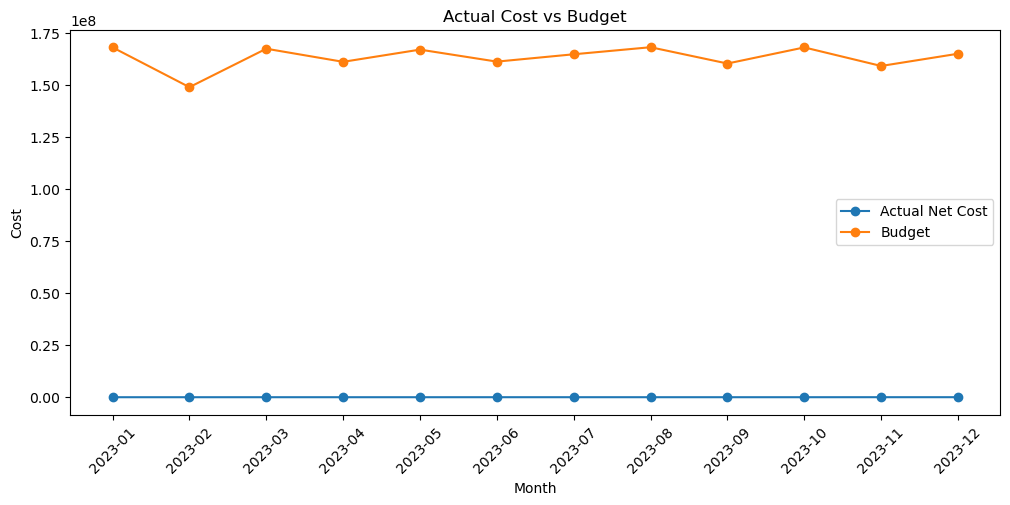

In [22]:
budget_analysis["period"] = budget_analysis["year"].astype(str) + "-" + budget_analysis["month"].astype(str).str.zfill(2)

plt.figure(figsize=(12, 5))
plt.plot(budget_analysis["period"], budget_analysis["total_net_cost"], marker="o", label="Actual Net Cost")
plt.plot(budget_analysis["period"], budget_analysis["total_budget"], marker="o", label="Budget")
plt.title("Actual Cost vs Budget")
plt.xlabel("Month")
plt.ylabel("Cost")
plt.xticks(rotation=45)
plt.legend()
plt.show()

## 11. Forecast vs Custo Real | Forecast vs Actual Cost

This section compares forecasted cloud spend against actual cloud spend.

Forecast accuracy is important for financial planning and proactive cost management.

In [23]:
forecast_analysis = (
    monthly
    .groupby(["year", "month"], as_index=False)
    .agg(
        total_net_cost=("total_net_cost", "sum"),
        total_projected_monthly_cost=("total_projected_monthly_cost", "sum")
    )
)

forecast_analysis["forecast_error"] = forecast_analysis["total_net_cost"] - forecast_analysis["total_projected_monthly_cost"]
forecast_analysis["forecast_error_pct"] = forecast_analysis["forecast_error"] / forecast_analysis["total_projected_monthly_cost"]

forecast_analysis

,year,month,total_net_cost,total_projected_monthly_cost,forecast_error,forecast_error_pct
0,2023,1,"29,886.60","121,770.00","-91,883.41",-0.75
1,2023,2,"29,145.86","113,606.19","-84,460.32",-0.74
2,2023,3,"33,317.25","132,534.25","-99,217.00",-0.75
3,2023,4,"31,226.57","120,025.87","-88,799.30",-0.74
4,2023,5,"32,336.58","134,608.27","-102,271.68",-0.76
5,2023,6,"36,288.11","146,836.50","-110,548.39",-0.75
6,2023,7,"36,638.34","150,108.23","-113,469.89",-0.76
7,2023,8,"33,066.69","137,469.84","-104,403.15",-0.76
8,2023,9,"31,408.53","120,546.26","-89,137.72",-0.74
9,2023,10,"32,675.05","129,664.25","-96,989.20",-0.75


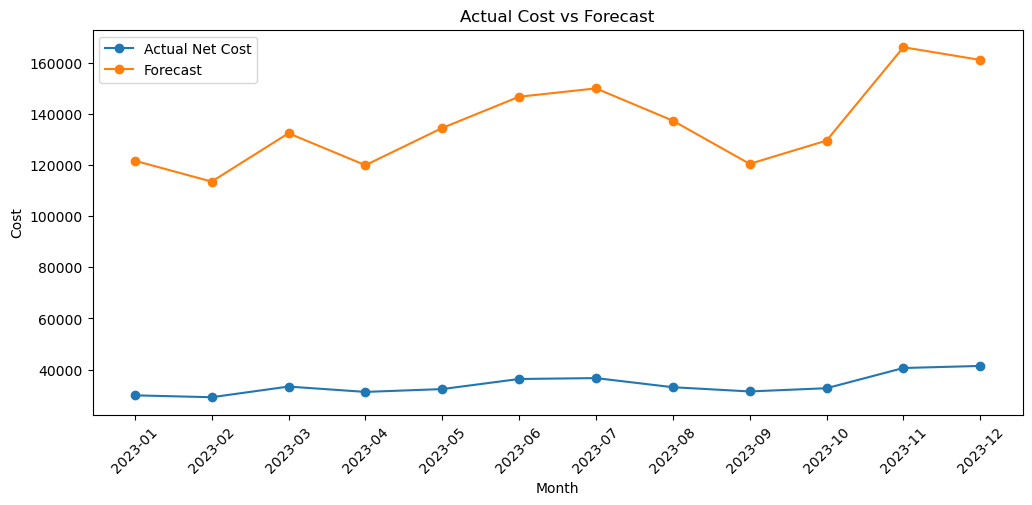

In [24]:
forecast_analysis["period"] = forecast_analysis["year"].astype(str) + "-" + forecast_analysis["month"].astype(str).str.zfill(2)

plt.figure(figsize=(12, 5))
plt.plot(forecast_analysis["period"], forecast_analysis["total_net_cost"], marker="o", label="Actual Net Cost")
plt.plot(forecast_analysis["period"], forecast_analysis["total_projected_monthly_cost"], marker="o", label="Forecast")
plt.title("Actual Cost vs Forecast")
plt.xlabel("Month")
plt.ylabel("Cost")
plt.xticks(rotation=45)
plt.legend()
plt.show()

## 12. Tendência Diária de Custos | Daily Cost Trend

This section analyzes daily cloud cost trends.

Daily monitoring helps detect unexpected cost increases and supports faster investigation of cost spikes.

In [25]:
daily_trend = (
    daily
    .groupby("date", as_index=False)
    .agg(
        total_net_cost=("total_net_cost", "sum"),
        anomaly_count=("anomaly_count", "sum")
    )
)

daily_trend.head()

,date,total_net_cost,anomaly_count
0,2023-01-01,769.94,0
1,2023-01-02,"1,127.42",0
2,2023-01-03,"1,010.13",0
3,2023-01-04,"1,037.11",0
4,2023-01-05,992.08,0


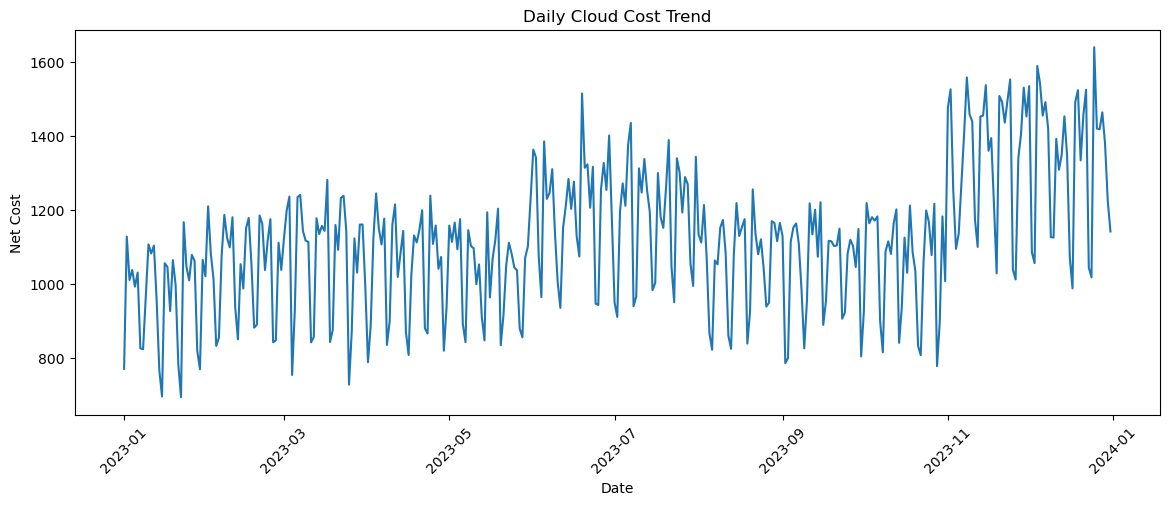

In [27]:
plt.figure(figsize=(14, 5))
plt.plot(daily_trend["date"], daily_trend["total_net_cost"])
plt.title("Daily Cloud Cost Trend")
plt.xlabel("Date")
plt.ylabel("Net Cost")
plt.xticks(rotation=45)
plt.show()

## 13. Detecção de Anomalias | Anomaly Detection

This section analyzes anomalous cloud cost behavior using the anomaly indicators available in the dataset.

Anomaly detection helps identify unexpected cost patterns that should be investigated with engineering teams.

#### Registros com `anomaly_score` acima do percentil 95 serão classificados como potenciais anomalias.

#### Records with an `anomaly_score` above the 95th percentile will be classified as potential anomalies.

In [30]:
anomaly_threshold = original["anomaly_score"].quantile(0.95)

original["custom_is_anomaly"] = original["anomaly_score"] >= anomaly_threshold

print("Anomaly threshold:", anomaly_threshold)
print(original["custom_is_anomaly"].value_counts())

Anomaly threshold: 0.5249549999999996
custom_is_anomaly
False    52012
True      2738
Name: count, dtype: int64


In [31]:
anomalies = original[original["custom_is_anomaly"] == True].copy()

anomalies_summary = (
    anomalies
    .groupby(["cloud_provider", "service", "environment"], as_index=False)
    .agg(
        anomaly_count=("custom_is_anomaly", "sum"),
        total_net_cost=("net_cost", "sum"),
        avg_anomaly_score=("anomaly_score", "mean")
    )
    .sort_values(["anomaly_count", "total_net_cost"], ascending=False)
)

anomalies_summary.head(10)

,cloud_provider,service,environment,anomaly_count,total_net_cost,avg_anomaly_score
43,GCP,Analytics,prod,94,"1,073.17",0.57
40,Azure,Storage,prod,88,780.49,0.56
58,GCP,Serverless,prod,88,597.90,0.56
13,AWS,Networking,prod,88,537.92,0.56
7,AWS,Container,prod,87,907.91,0.57
52,GCP,Database,prod,86,726.86,0.56
61,GCP,Storage,prod,86,651.87,0.56
28,Azure,Container,prod,82,804.82,0.57
10,AWS,Database,prod,80,891.86,0.57
19,AWS,Storage,prod,80,725.26,0.57


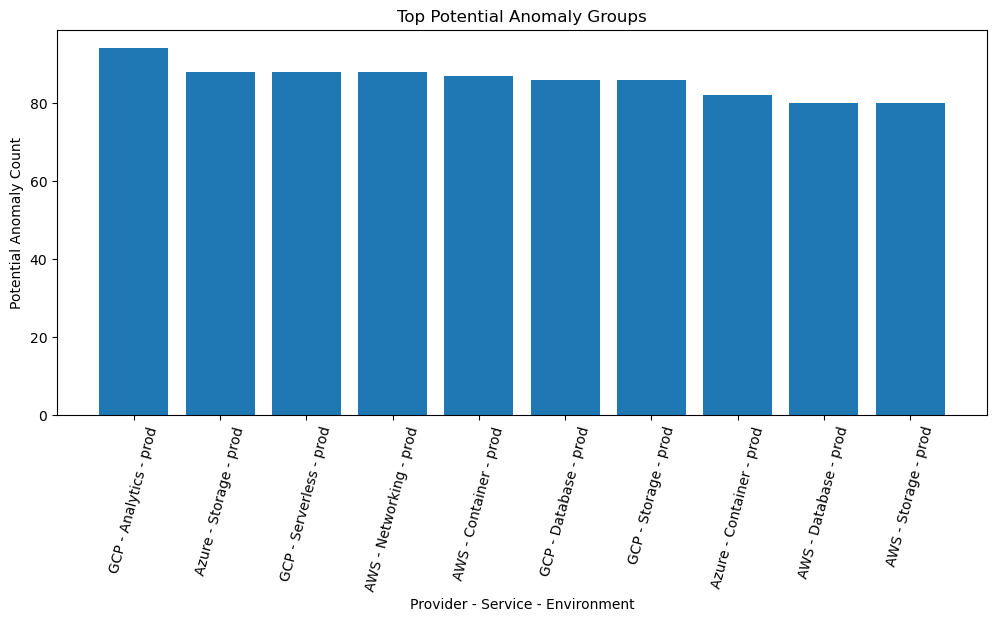

In [32]:
top_anomalies = anomalies_summary.head(10)

plt.figure(figsize=(12, 5))
plt.bar(
    top_anomalies["cloud_provider"] + " - " + top_anomalies["service"] + " - " + top_anomalies["environment"],
    top_anomalies["anomaly_count"]
)

plt.title("Top Potential Anomaly Groups")
plt.xlabel("Provider - Service - Environment")
plt.ylabel("Potential Anomaly Count")
plt.xticks(rotation=75)
plt.show()

## 14. Análise de Savings | Savings Analysis

This section analyzes discounts, Reserved Instance savings, Savings Plan savings and Spot savings.

Savings analysis helps evaluate how much the company is reducing costs through optimization strategies.

In [33]:
savings_analysis = (
    original
    .groupby("cloud_provider", as_index=False)
    .agg(
        list_cost=("list_cost", "sum"),
        net_cost=("net_cost", "sum"),
        discount_amount=("discount_amount", "sum"),
        reserved_savings=("reserved_savings", "sum"),
        savings_plan_savings=("savings_plan_savings", "sum"),
        spot_savings=("spot_savings", "sum")
    )
)

savings_analysis["effective_savings"] = savings_analysis["list_cost"] - savings_analysis["net_cost"]
savings_analysis["effective_savings_pct"] = savings_analysis["effective_savings"] / savings_analysis["list_cost"]

savings_analysis

,cloud_provider,list_cost,net_cost,discount_amount,reserved_savings,savings_plan_savings,spot_savings,effective_savings,effective_savings_pct
0,AWS,"184,909.04","143,328.96","41,580.08","8,377.74","9,705.22",855.06,"41,580.08",0.22
1,Azure,"173,137.81","134,175.77","38,962.05","7,765.15","8,992.20",806.57,"38,962.04",0.23
2,GCP,"168,453.36","130,475.27","37,978.10","7,469.81","8,880.82",751.92,"37,978.10",0.23


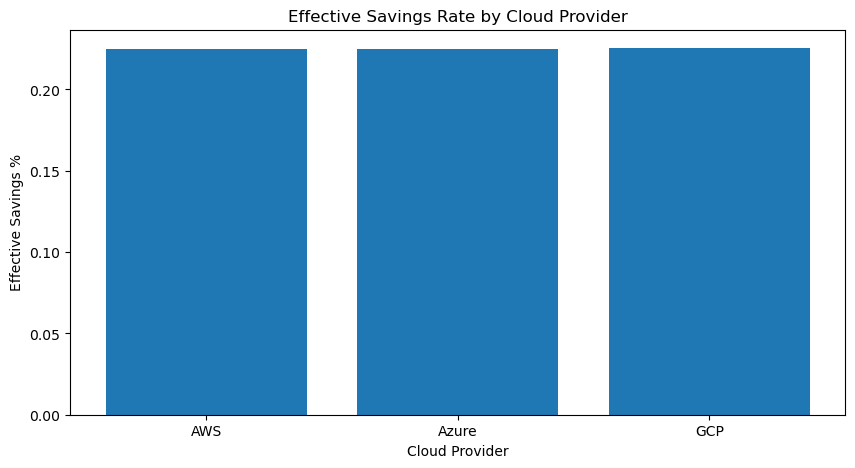

In [34]:
plt.figure(figsize=(10, 5))
plt.bar(savings_analysis["cloud_provider"], savings_analysis["effective_savings_pct"])
plt.title("Effective Savings Rate by Cloud Provider")
plt.xlabel("Cloud Provider")
plt.ylabel("Effective Savings %")
plt.show()

## 15. Cobertura de Savings Plans e Reserved Instances | Savings Plans and Reserved Instances Coverage

This section evaluates average Savings Plan coverage and Reserved Instance coverage by provider and service.

High-cost services with low commitment coverage may represent optimization opportunities.

In [35]:
coverage_analysis = (
    original
    .groupby(["cloud_provider", "service"], as_index=False)
    .agg(
        avg_savings_plan_coverage=("savings_plan_coverage_pct", "mean"),
        avg_reserved_instance_coverage=("reserved_instance_coverage_pct", "mean"),
        total_net_cost=("net_cost", "sum")
    )
    .sort_values("total_net_cost", ascending=False)
)

coverage_analysis.head(10)

,cloud_provider,service,avg_savings_plan_coverage,avg_reserved_instance_coverage,total_net_cost
0,AWS,Analytics,0.33,0.22,"26,554.98"
1,AWS,Compute,0.32,0.22,"25,972.36"
7,Azure,Analytics,0.31,0.22,"25,909.77"
14,GCP,Analytics,0.32,0.22,"24,655.35"
8,Azure,Compute,0.33,0.22,"23,162.18"
3,AWS,Database,0.32,0.23,"23,031.47"
15,GCP,Compute,0.32,0.22,"22,520.88"
2,AWS,Container,0.32,0.22,"22,466.48"
10,Azure,Database,0.32,0.22,"21,587.21"
17,GCP,Database,0.32,0.22,"21,357.23"


## 16. Custo por Business Unit | Cost by Business Unit

This section analyzes cloud costs by business unit.

Business unit analysis supports cost allocation, accountability, showback and chargeback models.

In [36]:
cost_by_bu = (
    original
    .groupby("business_unit", as_index=False)
    .agg(
        total_net_cost=("net_cost", "sum"),
        total_budget=("budget_amount", "sum"),
        anomaly_count=("is_anomaly", "sum")
    )
    .sort_values("total_net_cost", ascending=False)
)

cost_by_bu["budget_variance"] = cost_by_bu["total_net_cost"] - cost_by_bu["total_budget"]

cost_by_bu

,business_unit,total_net_cost,total_budget,anomaly_count,budget_variance
1,Finance,"82,745.00","392,014,846.60",0,"-391,932,101.60"
3,Marketing,"82,465.53","396,833,643.52",0,"-396,751,177.99"
2,HR,"81,759.98","393,821,790.74",0,"-393,740,030.76"
0,Engineering,"80,565.57","387,363,403.64",0,"-387,282,838.07"
4,Sales,"80,443.92","391,446,424.79",0,"-391,365,980.87"


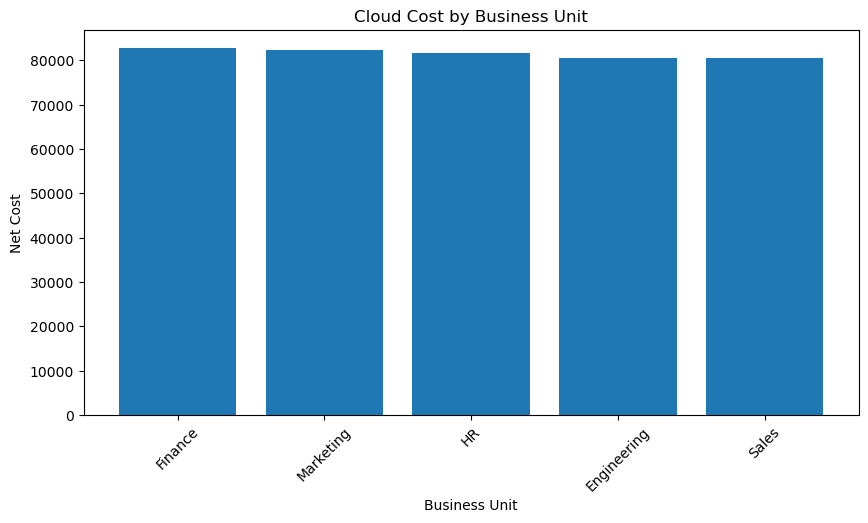

In [37]:
plt.figure(figsize=(10, 5))
plt.bar(cost_by_bu["business_unit"], cost_by_bu["total_net_cost"])
plt.title("Cloud Cost by Business Unit")
plt.xlabel("Business Unit")
plt.ylabel("Net Cost")
plt.xticks(rotation=45)
plt.show()

## 17. Custo por Departamento | Cost by Department

This section analyzes cloud costs by department.

Department-level cost visibility helps leadership understand which teams are responsible for cloud spend.

In [38]:
cost_by_department = (
    original
    .groupby("department", as_index=False)
    .agg(
        total_net_cost=("net_cost", "sum"),
        anomaly_count=("is_anomaly", "sum")
    )
    .sort_values("total_net_cost", ascending=False)
)

cost_by_department

,department,total_net_cost,anomaly_count
2,Mobile,"82,711.29",0
3,Security,"81,729.98",0
1,DataPlatform,"81,575.57",0
0,BI,"81,311.27",0
4,WebApps,"80,651.88",0


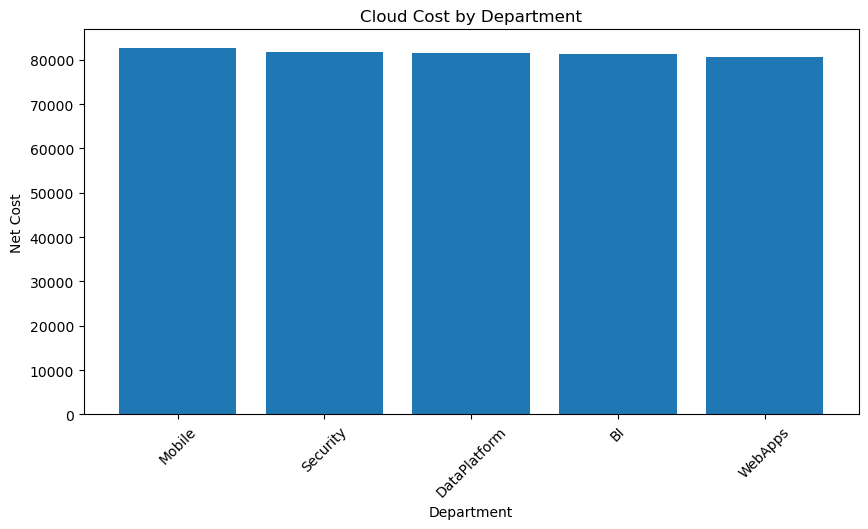

In [39]:
plt.figure(figsize=(10, 5))
plt.bar(cost_by_department["department"], cost_by_department["total_net_cost"])
plt.title("Cloud Cost by Department")
plt.xlabel("Department")
plt.ylabel("Net Cost")
plt.xticks(rotation=45)
plt.show()

## 18. Top Contas por Custo | Top Accounts by Cost

This section identifies the accounts with the highest cloud cost.

Account-level analysis helps prioritize governance, budget review and optimization actions.

In [40]:
top_accounts = (
    original
    .groupby("account_id", as_index=False)
    .agg(
        total_net_cost=("net_cost", "sum"),
        anomaly_count=("is_anomaly", "sum"),
        avg_budget_utilization=("budget_utilization_pct", "mean")
    )
    .sort_values("total_net_cost", ascending=False)
    .head(10)
)

top_accounts

,account_id,total_net_cost,anomaly_count,avg_budget_utilization
6,acct-007,"41,698.00",0,0.00
7,acct-008,"41,375.69",0,0.00
2,acct-003,"41,193.70",0,0.00
4,acct-005,"41,121.49",0,0.00
8,acct-009,"41,117.66",0,0.00
9,acct-010,"40,854.84",0,0.00
5,acct-006,"40,834.95",0,0.00
1,acct-002,"40,078.04",0,0.00
3,acct-004,"39,859.53",0,0.00
0,acct-001,"39,846.11",0,0.00


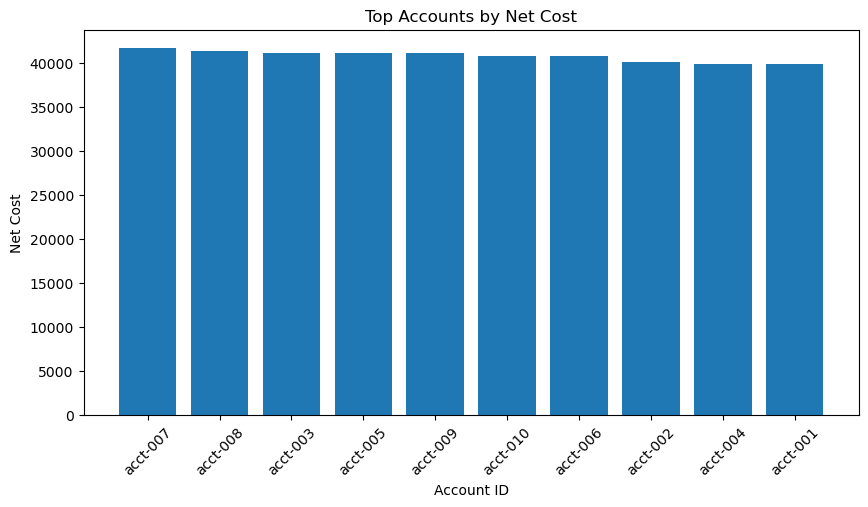

In [41]:
plt.figure(figsize=(10, 5))
plt.bar(top_accounts["account_id"], top_accounts["total_net_cost"])
plt.title("Top Accounts by Net Cost")
plt.xlabel("Account ID")
plt.ylabel("Net Cost")
plt.xticks(rotation=45)
plt.show()

## 19. Top Projetos por Custo | Top Projects by Cost

This section identifies the projects with the highest cloud cost.

Project-level analysis is important because optimization actions are usually executed by the teams responsible for each workload.

In [42]:
top_projects = (
    original
    .groupby("project_id", as_index=False)
    .agg(
        total_net_cost=("net_cost", "sum"),
        total_usage=("usage_quantity", "sum"),
        anomaly_count=("is_anomaly", "sum")
    )
    .sort_values("total_net_cost", ascending=False)
    .head(10)
)

top_projects

,project_id,total_net_cost,total_usage,anomaly_count
12,project-013,"27,622.27","309,064.19",0
8,project-009,"27,558.29","307,417.01",0
9,project-010,"27,474.47","308,238.55",0
3,project-004,"27,401.48","307,508.28",0
0,project-001,"27,274.51","308,182.27",0
11,project-012,"27,256.73","305,982.94",0
7,project-008,"27,214.49","305,943.21",0
6,project-007,"27,171.11","307,309.47",0
5,project-006,"27,143.62","305,830.08",0
13,project-014,"27,106.13","306,369.54",0


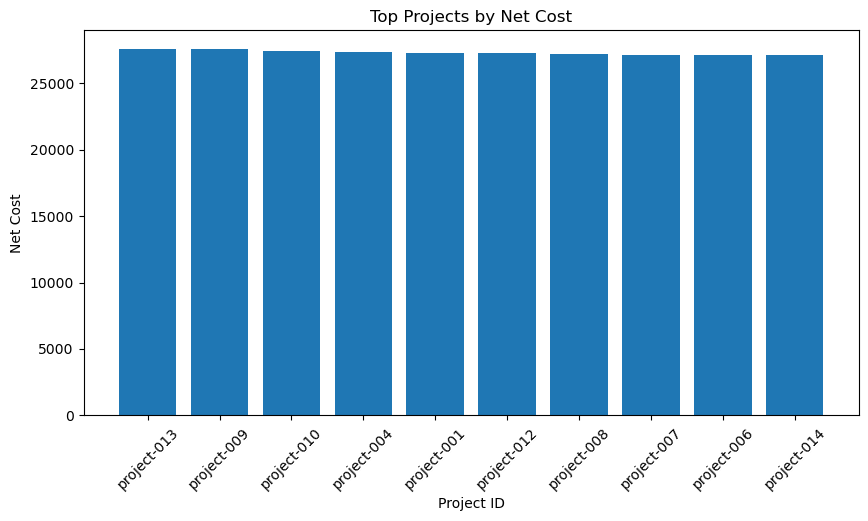

In [43]:
plt.figure(figsize=(10, 5))
plt.bar(top_projects["project_id"], top_projects["total_net_cost"])
plt.title("Top Projects by Net Cost")
plt.xlabel("Project ID")
plt.ylabel("Net Cost")
plt.xticks(rotation=45)
plt.show()

## 20. Recomendações de Otimização | Optimization Recommendations

This section generates cost optimization recommendations based on high cost, low commitment coverage and potential savings opportunities.

Esta seção gera recomendações de otimização com base em alto custo, baixa cobertura de compromisso e oportunidades potenciais de economia.

The goal is to provide actionable recommendations that could be shared with leadership and engineering teams.

O objetivo é fornecer recomendações acionáveis que poderiam ser compartilhadas com a liderança e os times de engenharia.

In [45]:
optimization_opportunities = coverage_analysis.copy()

optimization_opportunities["avg_commitment_coverage"] = (
    optimization_opportunities["avg_savings_plan_coverage"] +
    optimization_opportunities["avg_reserved_instance_coverage"]
) / 2

optimization_opportunities["low_commitment_coverage"] = (
    optimization_opportunities["avg_commitment_coverage"] < 0.5
)

optimization_opportunities["high_cost"] = (
    optimization_opportunities["total_net_cost"] >= optimization_opportunities["total_net_cost"].quantile(0.70)
)

optimization_opportunities["priority_score"] = (
    optimization_opportunities["total_net_cost"] *
    (1 - optimization_opportunities["avg_commitment_coverage"])
)

optimization_opportunities = optimization_opportunities.sort_values(
    "priority_score",
    ascending=False
)

optimization_opportunities.head(10)

,cloud_provider,service,avg_savings_plan_coverage,avg_reserved_instance_coverage,total_net_cost,avg_commitment_coverage,low_commitment_coverage,high_cost,priority_score
0,AWS,Analytics,0.33,0.22,"26,554.98",0.27,True,True,"19,311.75"
7,Azure,Analytics,0.31,0.22,"25,909.77",0.27,True,True,"18,964.47"
1,AWS,Compute,0.32,0.22,"25,972.36",0.27,True,True,"18,894.22"
14,GCP,Analytics,0.32,0.22,"24,655.35",0.27,True,True,"18,019.40"
8,Azure,Compute,0.33,0.22,"23,162.18",0.27,True,True,"16,886.31"
3,AWS,Database,0.32,0.23,"23,031.47",0.27,True,True,"16,792.65"
2,AWS,Container,0.32,0.22,"22,466.48",0.27,True,False,"16,438.34"
15,GCP,Compute,0.32,0.22,"22,520.88",0.27,True,True,"16,390.22"
10,Azure,Database,0.32,0.22,"21,587.21",0.27,True,False,"15,793.15"
17,GCP,Database,0.32,0.22,"21,357.23",0.27,True,False,"15,541.52"


In [46]:
recommendations = []

for _, row in optimization_opportunities.head(15).iterrows():
    if row["high_cost"] and row["low_commitment_coverage"]:
        issue = "High cost with low commitment coverage"
        recommendation = "Review workload stability and evaluate Savings Plans or Reserved Instances."
        priority = "High"
    elif row["high_cost"]:
        issue = "High cost service"
        recommendation = "Investigate cost drivers, usage patterns and rightsizing opportunities."
        priority = "Medium"
    elif row["low_commitment_coverage"]:
        issue = "Low commitment coverage"
        recommendation = "Evaluate whether the workload is stable enough for commitment-based discounts."
        priority = "Medium"
    else:
        issue = "Optimization candidate"
        recommendation = "Monitor usage and validate if optimization actions are required."
        priority = "Low"
    
    recommendations.append({
        "cloud_provider": row["cloud_provider"],
        "service": row["service"],
        "total_net_cost": row["total_net_cost"],
        "avg_savings_plan_coverage": row["avg_savings_plan_coverage"],
        "avg_reserved_instance_coverage": row["avg_reserved_instance_coverage"],
        "avg_commitment_coverage": row["avg_commitment_coverage"],
        "priority_score": row["priority_score"],
        "priority": priority,
        "issue": issue,
        "recommendation": recommendation
    })

recommendations_df = pd.DataFrame(recommendations)

recommendations_df.head(10)

,cloud_provider,service,total_net_cost,avg_savings_plan_coverage,avg_reserved_instance_coverage,avg_commitment_coverage,priority_score,priority,issue,recommendation
0,AWS,Analytics,"26,554.98",0.33,0.22,0.27,"19,311.75",High,High cost with low commitment coverage,Review workload stability and evaluate Savings...
1,Azure,Analytics,"25,909.77",0.31,0.22,0.27,"18,964.47",High,High cost with low commitment coverage,Review workload stability and evaluate Savings...
2,AWS,Compute,"25,972.36",0.32,0.22,0.27,"18,894.22",High,High cost with low commitment coverage,Review workload stability and evaluate Savings...
3,GCP,Analytics,"24,655.35",0.32,0.22,0.27,"18,019.40",High,High cost with low commitment coverage,Review workload stability and evaluate Savings...
4,Azure,Compute,"23,162.18",0.33,0.22,0.27,"16,886.31",High,High cost with low commitment coverage,Review workload stability and evaluate Savings...
5,AWS,Database,"23,031.47",0.32,0.23,0.27,"16,792.65",High,High cost with low commitment coverage,Review workload stability and evaluate Savings...
6,AWS,Container,"22,466.48",0.32,0.22,0.27,"16,438.34",Medium,Low commitment coverage,Evaluate whether the workload is stable enough...
7,GCP,Compute,"22,520.88",0.32,0.22,0.27,"16,390.22",High,High cost with low commitment coverage,Review workload stability and evaluate Savings...
8,Azure,Database,"21,587.21",0.32,0.22,0.27,"15,793.15",Medium,Low commitment coverage,Evaluate whether the workload is stable enough...
9,GCP,Database,"21,357.23",0.32,0.22,0.27,"15,541.52",Medium,Low commitment coverage,Evaluate whether the workload is stable enough...


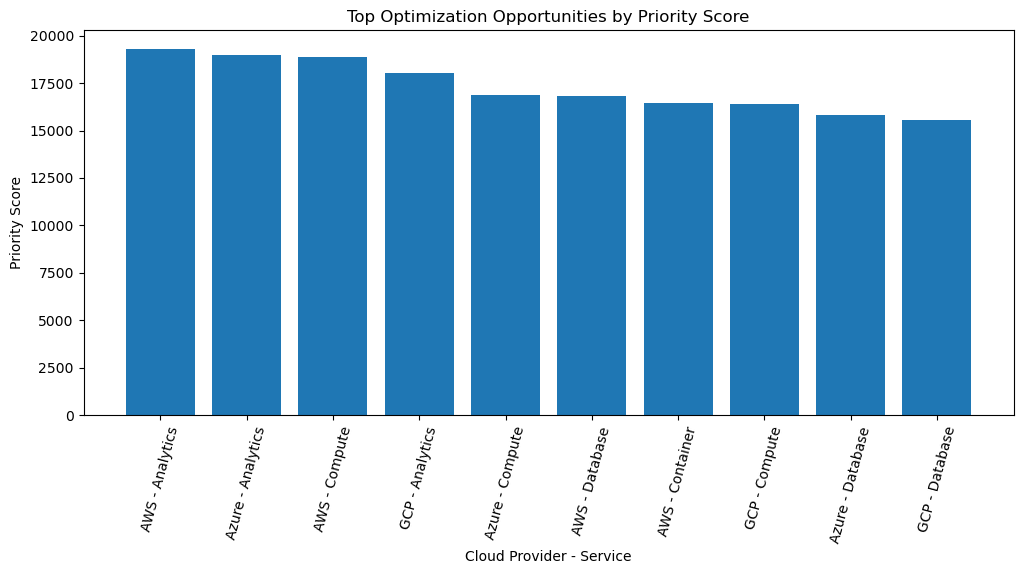

In [47]:
top_recommendations = recommendations_df.head(10)

plt.figure(figsize=(12, 5))
plt.bar(
    top_recommendations["cloud_provider"] + " - " + top_recommendations["service"],
    top_recommendations["priority_score"]
)

plt.title("Top Optimization Opportunities by Priority Score")
plt.xlabel("Cloud Provider - Service")
plt.ylabel("Priority Score")
plt.xticks(rotation=75)
plt.show()

#### I created a recommendation logic that prioritizes high-cost services with low commitment coverage. Instead of only filtering records, I created a priority score based on total net cost and average commitment coverage. This helps rank optimization opportunities and makes the output more useful for leadership and engineering teams.

Eu criei uma lógica de recomendação que prioriza serviços de alto custo com baixa cobertura de compromisso. Em vez de apenas filtrar registros, criei um score de prioridade baseado no custo líquido total e na cobertura média de compromisso. Isso ajuda a ranquear oportunidades de otimização e torna o resultado mais útil para liderança e times de engenharia.

## 21. Análise de Tags | Tagging Analysis

This section evaluates tag availability and tagging quality.

Tagging is fundamental in FinOps because it enables cost allocation, ownership, showback, chargeback and accountability.

In [48]:
original["has_tags"] = original["tags"].notnull()

tag_coverage = original["has_tags"].mean()

print(f"Tag coverage: {tag_coverage:.2%}")

Tag coverage: 100.00%


In [49]:
tag_analysis = (
    original
    .groupby("has_tags", as_index=False)
    .agg(
        row_count=("date", "count"),
        total_net_cost=("net_cost", "sum")
    )
)

tag_analysis

,has_tags,row_count,total_net_cost
0,True,54750,"407,980.00"


## 22. Geração do Arquivo Final de KPIs | Final KPI File Generation

This section creates the final processed KPI file to be saved in the `data/processed` folder.

The output file can be used for dashboards, reporting or future AWS integration.

In [51]:
final_kpis = (
    original
    .groupby(["year_month", "cloud_provider", "account_id", "environment"], as_index=False)
    .agg(
        total_list_cost=("list_cost", "sum"),
        total_net_cost=("net_cost", "sum"),
        total_on_demand_cost=("on_demand_cost", "sum"),
        total_amortized_cost=("amortized_cost", "sum"),
        total_forecast_monthly_cost=("forecast_monthly_cost", "sum"),
        total_budget_amount=("budget_amount", "sum"),
        avg_budget_utilization_pct=("budget_utilization_pct", "mean"),
        avg_cost_variance_7d_pct=("cost_variance_7d_pct", "mean"),
        avg_cost_variance_30d_pct=("cost_variance_30d_pct", "mean"),
        anomaly_count=("is_anomaly", "sum"),
        row_count=("date", "count")
    )
)

final_kpis.to_csv("finops_kpis.csv", index=False)

final_kpis.head()

,year_month,cloud_provider,account_id,environment,total_list_cost,total_net_cost,total_on_demand_cost,total_amortized_cost,total_forecast_monthly_cost,total_budget_amount,avg_budget_utilization_pct,avg_cost_variance_7d_pct,avg_cost_variance_30d_pct,anomaly_count,row_count
0,2023-01,AWS,acct-001,dev,63.11,50.42,38.27,47.37,183.62,"165,763.30",0.00,0.05,-0.07,0,20
1,2023-01,AWS,acct-001,prod,"1,180.10",940.35,363.39,815.11,"3,940.39","5,176,122.24",0.00,0.02,0.06,0,100
2,2023-01,AWS,acct-001,staging,185.86,140.62,69.50,120.63,618.63,"522,613.77",0.00,-0.06,0.07,0,34
3,2023-01,AWS,acct-002,dev,86.56,66.86,50.22,61.83,191.26,"206,968.52",0.00,0.07,0.04,0,25
4,2023-01,AWS,acct-002,prod,"1,019.81",783.38,295.28,670.20,"3,601.46","4,962,704.29",0.00,0.02,0.05,0,96


## 23. Resumo Executivo | Executive Summary

This analysis simulated a Cloud FinOps workflow focused on cloud cost visibility, budget control, anomaly detection, forecasting and optimization opportunities.

Main outcomes:

- Identified the main cloud cost drivers by provider, service, environment, account and business unit.
- Compared actual costs against budget and forecast.
- Detected anomalous cost behavior using the anomaly fields available in the dataset.
- Evaluated savings generated by discounts, Reserved Instances, Savings Plans and Spot usage.
- Created optimization recommendations based on high-cost services with low commitment coverage.

Recommended actions:

- Review high-cost services with low Savings Plan or Reserved Instance coverage.
- Investigate cost anomalies by account, project and environment.
- Improve budget tracking for teams with increasing cost trends.
- Strengthen tagging governance for better cost allocation.
- Use daily monitoring to detect unexpected cost increases earlier.